# app

08 - CV Active Brazing Trigger

Финальное исследование лёгкого OpenCV-триггера начала активной пайки.

Цель ноутбука:

1. Использовать OpenCV-признаки, рассчитанные по ROI зоны пайки.
2. Построить дополнительные временные признаки: diff, rolling mean, rolling std.
3. Проверить несколько CV trigger score.
4. Подобрать threshold и confirm_frames.
5. Оценить ошибку времени срабатывания относительно начала `active_brazing`.
6. Сравнить CV-trigger с trigger на основе `P(active_brazing)` из нейросетевой модели.

Главная метрика — не покадровая accuracy, а ошибка времени срабатывания:

```text
error_s = pred_active_brazing_start_s - true_active_brazing_start_s

## bootstrap

In [1]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## env

In [3]:
FPS = 10
ROOT = Path()
DRIVE_FOLDER = Path('/content/drive/MyDrive/Colab Notebooks/Diploma')

In [4]:
DATA = ROOT / "data" 

DATA_ANNOTATIONS = DATA / "annotations" 
STAGE_INTERVALS_PATH = DATA_ANNOTATIONS / "stage_intervals.csv"
SPLITS_DIR = DATA_ANNOTATIONS / f"splits_{FPS}"
TRAIN_PATH = SPLITS_DIR / "train.csv"
VAL_PATH = SPLITS_DIR / "val.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

assert STAGE_INTERVALS_PATH.exists(), STAGE_INTERVALS_PATH
assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH

In [5]:
REPORTS = ROOT / "reports" 

CV_FEATURES_PATH = REPORTS / "cv_features_10" / "frame_features_roi.csv"
STAGE_PROB_TRIGGER_SUMMARY_PATH = REPORTS / "active_brazing_trigger" / "trigger_methods_summary.csv"

OUTPUT_DIR = REPORTS/ "cv_active_brazing_trigger"
FIGURES_DIR = REPORTS / "figures" / "cv_active_brazing_trigger"

assert CV_FEATURES_PATH.exists(), CV_FEATURES_PATH
assert STAGE_PROB_TRIGGER_SUMMARY_PATH.exists(), STAGE_PROB_TRIGGER_SUMMARY_PATH
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

ACTIVE_STAGE = "active_brazing"
ACTIVE_STAGE_ID = STAGE_TO_ID[ACTIVE_STAGE]

# lib

# model

# runtime

In [7]:
cv_features_df = pd.read_csv(CV_FEATURES_PATH)
intervals_df = pd.read_csv(STAGE_INTERVALS_PATH)

train_split_df = pd.read_csv(TRAIN_PATH)
val_split_df = pd.read_csv(VAL_PATH)
test_split_df = pd.read_csv(TEST_PATH)

cv_features_df = cv_features_df.sort_values(["video_id", "timestamp_s"]).reset_index(drop=True)

print("CV features:", cv_features_df.shape)
print("train:", train_split_df.shape)
print("val:", val_split_df.shape)
print("test:", test_split_df.shape)

cv_features_df.head()

CV features: (10442, 27)
train: (5755, 8)
val: (1091, 8)
test: (1732, 8)


,video_id,frame_path,timestamp_s,stage_id,stage_name,brightness_mean,brightness_std,value_mean,value_std,saturation_mean,...,blue_mean,red_green_diff,red_blue_diff,white_area_ratio,specular_highlight_ratio,dark_area_ratio,warm_area_ratio,edge_density,laplacian_var,frame_diff_score
0,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.0,0,inactive_preparation,145.025702,56.764680,179.579174,59.605029,81.634146,...,178.895822,-24.509840,-54.469326,0.186183,0.295285,0.001684,0.000513,0.047298,63.083993,0.000000
1,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.1,0,inactive_preparation,145.016095,56.783864,179.602422,59.669960,81.694956,...,178.921460,-24.559415,-54.543208,0.184820,0.295854,0.002823,0.000104,0.044876,57.582917,5.643208
2,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.2,0,inactive_preparation,144.746600,56.941886,179.331492,59.928375,81.702783,...,178.628436,-24.466239,-54.456864,0.185397,0.295573,0.002326,0.001018,0.043881,52.329581,6.892799
3,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.3,0,inactive_preparation,144.179238,56.860416,178.766520,60.059887,81.878757,...,178.066095,-24.425670,-54.440866,0.182013,0.292221,0.002694,0.000217,0.045261,58.514641,6.039647
4,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.4,0,inactive_preparation,143.328941,56.569369,177.997971,60.045856,82.211307,...,177.244731,-24.299808,-54.387987,0.176135,0.283593,0.003144,0.000730,0.043111,55.663785,10.602550


## true active_brazing start times

In [8]:
active_intervals_df = intervals_df[
    intervals_df["stage_name"] == ACTIVE_STAGE
].copy()

true_active_start_df = active_intervals_df[[
    "video_id",
    "start_s",
    "end_s",
]].rename(columns={
    "start_s": "true_active_brazing_start_s",
    "end_s": "true_active_brazing_end_s",
})

test_video_ids = sorted(test_split_df["video_id"].unique())

true_active_start_df = true_active_start_df[
    true_active_start_df["video_id"].isin(test_video_ids)
].copy().reset_index(drop=True)

true_active_start_df

,video_id,true_active_brazing_start_s,true_active_brazing_end_s
0,MVI_6265,34.0,39.6
1,MVI_6266,30.8,40.8
2,MVI_6279,49.0,53.0


## split CV features

In [9]:
train_paths = set(train_split_df["frame_path"])
val_paths = set(val_split_df["frame_path"])
test_paths = set(test_split_df["frame_path"])

cv_train_df = cv_features_df[cv_features_df["frame_path"].isin(train_paths)].copy()
cv_val_df = cv_features_df[cv_features_df["frame_path"].isin(val_paths)].copy()
cv_test_df = cv_features_df[cv_features_df["frame_path"].isin(test_paths)].copy()

for part_df in [cv_train_df, cv_val_df, cv_test_df]:
    part_df["binary_active_brazing"] = (
        part_df["stage_name"] == ACTIVE_STAGE
    ).astype(int)

print(cv_train_df.shape, cv_val_df.shape, cv_test_df.shape)

pd.DataFrame({
    "train": cv_train_df.groupby("stage_name").size().reindex(STAGE_ORDER),
    "val": cv_val_df.groupby("stage_name").size().reindex(STAGE_ORDER),
    "test": cv_test_df.groupby("stage_name").size().reindex(STAGE_ORDER),
})

(5755, 28) (1091, 28) (1732, 28)


,train,val,test
stage_name,,,
inactive_preparation,3552,734,1000
flux_activation,506,102,138
active_brazing,766,138,196
stabilization,931,117,398


## Part-1: temporal_features

In [10]:
BASE_FEATURES_FOR_TEMPORAL = [
    "brightness_mean",
    "value_mean",
    "saturation_mean",
    "white_area_ratio",
    "specular_highlight_ratio",
    "edge_density",
    "laplacian_var",
    "frame_diff_score",
    "warm_area_ratio",
]


def add_temporal_features(
    df: pd.DataFrame,
    base_features: list[str],
    windows: list[int] = [3, 5, 10],
) -> pd.DataFrame:
    df = df.sort_values(["video_id", "timestamp_s"]).copy()

    for feature in base_features:
        if feature not in df.columns:
            print(f"skip missing feature: {feature}")
            continue

        df[f"{feature}_diff"] = (
            df.groupby("video_id")[feature]
            .diff()
            .fillna(0.0)
        )

        df[f"{feature}_abs_diff"] = df[f"{feature}_diff"].abs()

        for window in windows:
            df[f"{feature}_roll_mean_{window}"] = (
                df.groupby("video_id")[feature]
                .rolling(window, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )

            df[f"{feature}_roll_std_{window}"] = (
                df.groupby("video_id")[feature]
                .rolling(window, min_periods=1)
                .std()
                .reset_index(level=0, drop=True)
                .fillna(0.0)
            )

            df[f"{feature}_diff_roll_mean_{window}"] = (
                df.groupby("video_id")[f"{feature}_diff"]
                .rolling(window, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )

            df[f"{feature}_abs_diff_roll_mean_{window}"] = (
                df.groupby("video_id")[f"{feature}_abs_diff"]
                .rolling(window, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )

    return df


cv_train_df = add_temporal_features(cv_train_df, BASE_FEATURES_FOR_TEMPORAL)
cv_val_df = add_temporal_features(cv_val_df, BASE_FEATURES_FOR_TEMPORAL)
cv_test_df = add_temporal_features(cv_test_df, BASE_FEATURES_FOR_TEMPORAL)

cv_test_df.head()

/tmp/ipykernel_120130/3258645389.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{feature}_abs_diff_roll_mean_{window}"] = (
/tmp/ipykernel_120130/3258645389.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{feature}_diff"] = (
/tmp/ipykernel_120130/3258645389.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 

,video_id,frame_path,timestamp_s,stage_id,stage_name,brightness_mean,brightness_std,value_mean,value_std,saturation_mean,...,warm_area_ratio_diff_roll_mean_3,warm_area_ratio_abs_diff_roll_mean_3,warm_area_ratio_roll_mean_5,warm_area_ratio_roll_std_5,warm_area_ratio_diff_roll_mean_5,warm_area_ratio_abs_diff_roll_mean_5,warm_area_ratio_roll_mean_10,warm_area_ratio_roll_std_10,warm_area_ratio_diff_roll_mean_10,warm_area_ratio_abs_diff_roll_mean_10
0,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.0,0,inactive_preparation,145.025702,56.764680,179.579174,59.605029,81.634146,...,0.000000,0.000000,0.000513,0.000000,0.000000,0.000000,0.000513,0.000000,0.000000,0.000000
1,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.1,0,inactive_preparation,145.016095,56.783864,179.602422,59.669960,81.694956,...,-0.000204,0.000204,0.000309,0.000289,-0.000204,0.000204,0.000309,0.000289,-0.000204,0.000204
2,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.2,0,inactive_preparation,144.746600,56.941886,179.331492,59.928375,81.702783,...,0.000168,0.000441,0.000545,0.000458,0.000168,0.000441,0.000545,0.000458,0.000168,0.000441
3,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.3,0,inactive_preparation,144.179238,56.860416,178.766520,60.059887,81.878757,...,-0.000099,0.000708,0.000463,0.000408,-0.000074,0.000531,0.000463,0.000408,-0.000074,0.000531
4,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.4,0,inactive_preparation,143.328941,56.569369,177.997971,60.045856,82.211307,...,0.000209,0.000743,0.000516,0.000373,0.000043,0.000528,0.000516,0.000373,0.000043,0.000528


### event detection helpers

In [11]:
def detect_first_trigger_time(
    video_df: pd.DataFrame,
    score_col: str,
    threshold: float,
    confirm_frames: int,
) -> float | None:
    video_df = video_df.sort_values("timestamp_s").copy()

    scores = video_df[score_col].to_numpy()
    times = video_df["timestamp_s"].to_numpy()

    consecutive = 0

    for i, score in enumerate(scores):
        if score >= threshold:
            consecutive += 1
        else:
            consecutive = 0

        if consecutive >= confirm_frames:
            trigger_idx = i - confirm_frames + 1
            return float(times[trigger_idx])

    return None


def evaluate_event_trigger(
    df: pd.DataFrame,
    true_start_df: pd.DataFrame,
    score_col: str,
    threshold: float,
    confirm_frames: int,
    tolerance_s_values=(1.0, 2.0),
) -> pd.DataFrame:
    rows = []

    for video_id, video_df in df.groupby("video_id"):
        true_row = true_start_df[true_start_df["video_id"] == video_id]

        if len(true_row) == 0:
            continue

        true_start_s = float(true_row["true_active_brazing_start_s"].iloc[0])

        pred_start_s = detect_first_trigger_time(
            video_df,
            score_col=score_col,
            threshold=threshold,
            confirm_frames=confirm_frames,
        )

        if pred_start_s is None:
            error_s = np.nan
            abs_error_s = np.nan
            trigger_type = "missed"
        else:
            error_s = pred_start_s - true_start_s
            abs_error_s = abs(error_s)

            if error_s < 0:
                trigger_type = "early"
            elif error_s > 0:
                trigger_type = "late"
            else:
                trigger_type = "exact"

        row = {
            "video_id": video_id,
            "true_start_s": true_start_s,
            "pred_start_s": pred_start_s,
            "error_s": error_s,
            "abs_error_s": abs_error_s,
            "trigger_type": trigger_type,
            "threshold": threshold,
            "confirm_frames": confirm_frames,
            "score_col": score_col,
        }

        for tol in tolerance_s_values:
            row[f"within_{tol:.1f}s"] = (
                False if np.isnan(abs_error_s) else abs_error_s <= tol
            )

        rows.append(row)

    return pd.DataFrame(rows)


def summarize_event_results(event_df: pd.DataFrame) -> dict:
    valid_df = event_df.dropna(subset=["abs_error_s"]).copy()

    summary = {
        "num_videos": int(len(event_df)),
        "num_detected": int(len(valid_df)),
        "num_missed": int((event_df["trigger_type"] == "missed").sum()),
        "num_early": int((event_df["trigger_type"] == "early").sum()),
        "num_late": int((event_df["trigger_type"] == "late").sum()),
    }

    if len(valid_df) > 0:
        summary.update({
            "mae_s": float(valid_df["abs_error_s"].mean()),
            "mean_error_s": float(valid_df["error_s"].mean()),
            "median_abs_error_s": float(valid_df["abs_error_s"].median()),
            "max_abs_error_s": float(valid_df["abs_error_s"].max()),
        })

        for col in valid_df.columns:
            if col.startswith("within_"):
                summary[col] = float(valid_df[col].mean())

    return summary

### plot helper

In [12]:
def plot_trigger_timeline(
    df: pd.DataFrame,
    true_start_df: pd.DataFrame,
    video_id: str,
    score_col: str,
    threshold: float,
    confirm_frames: int,
    output_name: str,
):
    video_df = df[df["video_id"] == video_id].sort_values("timestamp_s").copy()

    true_start_s = float(
        true_start_df[true_start_df["video_id"] == video_id]
        ["true_active_brazing_start_s"]
        .iloc[0]
    )

    pred_start_s = detect_first_trigger_time(
        video_df,
        score_col=score_col,
        threshold=threshold,
        confirm_frames=confirm_frames,
    )

    plt.figure(figsize=(15, 5))

    plt.plot(
        video_df["timestamp_s"],
        video_df[score_col],
        label=score_col,
        linewidth=2,
    )

    plt.axhline(
        threshold,
        linestyle="--",
        label=f"threshold={threshold}",
    )

    plt.axvline(
        true_start_s,
        linestyle="-",
        linewidth=2,
        label=f"true active start: {true_start_s:.2f}s",
    )

    if pred_start_s is not None:
        plt.axvline(
            pred_start_s,
            linestyle=":",
            linewidth=2,
            label=f"pred trigger: {pred_start_s:.2f}s",
        )

    stage_scaled = video_df["stage_id"] / 3.0

    plt.plot(
        video_df["timestamp_s"],
        stage_scaled,
        alpha=0.25,
        label="true stage / 3",
    )

    plt.ylim(-0.05, 1.05)
    plt.xlabel("Time, s")
    plt.ylabel("Trigger score")
    plt.title(f"CV active brazing trigger timeline — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / output_name
    plt.savefig(output_path, dpi=160)
    plt.show()

## Part-2: improved CV-rule scores

In [13]:
def minmax_by_video(df: pd.DataFrame, col: str) -> pd.Series:
    parts = []

    for video_id, video_df in df.groupby("video_id"):
        s = video_df[col].astype(float)

        if s.max() > s.min():
            norm = (s - s.min()) / (s.max() - s.min())
        else:
            norm = s * 0.0

        parts.append(norm)

    return pd.concat(parts).sort_index()


def zscore_by_video(df: pd.DataFrame, col: str) -> pd.Series:
    parts = []

    for video_id, video_df in df.groupby("video_id"):
        s = video_df[col].astype(float)
        std = s.std()

        if std == 0 or np.isnan(std):
            z = s * 0.0
        else:
            z = (s - s.mean()) / std

        parts.append(z)

    return pd.concat(parts).sort_index()


def add_normalized_columns(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in cols:
        if col not in df.columns:
            continue

        df[f"z_{col}"] = zscore_by_video(df, col)
        df[f"mm_{col}"] = minmax_by_video(df, col)

    return df

### build CV trigger scores

In [14]:
SCORE_SOURCE_COLUMNS = [
    "frame_diff_score",
    "laplacian_var",
    "edge_density",
    "specular_highlight_ratio",
    "white_area_ratio",
    "frame_diff_score_abs_diff_roll_mean_5",
    "laplacian_var_abs_diff_roll_mean_5",
    "edge_density_abs_diff_roll_mean_5",
    "specular_highlight_ratio_abs_diff_roll_mean_5",
    "white_area_ratio_abs_diff_roll_mean_5",
]

cv_train_df = add_normalized_columns(cv_train_df, SCORE_SOURCE_COLUMNS)
cv_val_df = add_normalized_columns(cv_val_df, SCORE_SOURCE_COLUMNS)
cv_test_df = add_normalized_columns(cv_test_df, SCORE_SOURCE_COLUMNS)


def add_cv_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Old baseline score.
    df["score_cv_v1_motion_texture"] = (
        df["mm_frame_diff_score"]
        + df["mm_laplacian_var"]
        + df["mm_edge_density"]
        + 0.5 * df["mm_specular_highlight_ratio"]
    ) / 3.5

    # More focused on active changes.
    df["score_cv_v2_temporal_change"] = (
        df["mm_frame_diff_score_abs_diff_roll_mean_5"]
        + df["mm_laplacian_var_abs_diff_roll_mean_5"]
        + df["mm_edge_density_abs_diff_roll_mean_5"]
        + df["mm_specular_highlight_ratio_abs_diff_roll_mean_5"]
    ) / 4.0

    # Mix of current texture and temporal change.
    df["score_cv_v3_mixed"] = (
        0.35 * df["score_cv_v1_motion_texture"]
        + 0.65 * df["score_cv_v2_temporal_change"]
    )

    # Specular + motion.
    df["score_cv_v4_specular_motion"] = (
        0.45 * df["mm_specular_highlight_ratio"]
        + 0.35 * df["mm_frame_diff_score"]
        + 0.20 * df["mm_specular_highlight_ratio_abs_diff_roll_mean_5"]
    )

    return df


cv_train_df = add_cv_scores(cv_train_df)
cv_val_df = add_cv_scores(cv_val_df)
cv_test_df = add_cv_scores(cv_test_df)

cv_score_cols = [
    "score_cv_v1_motion_texture",
    "score_cv_v2_temporal_change",
    "score_cv_v3_mixed",
    "score_cv_v4_specular_motion",
]

cv_test_df[["video_id", "timestamp_s", "stage_name", *cv_score_cols]].head()

,video_id,timestamp_s,stage_name,score_cv_v1_motion_texture,score_cv_v2_temporal_change,score_cv_v3_mixed,score_cv_v4_specular_motion
0,MVI_6265,0.0,inactive_preparation,0.264918,0.000000,0.092721,0.198743
1,MVI_6265,0.1,inactive_preparation,0.302746,0.358397,0.338919,0.373571
2,MVI_6265,0.2,inactive_preparation,0.252706,0.376952,0.333466,0.410768
3,MVI_6265,0.3,inactive_preparation,0.327521,0.414500,0.384057,0.390129
4,MVI_6265,0.4,inactive_preparation,0.372033,0.460332,0.429427,0.534489


### grid search CV rule triggers

In [15]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
confirm_frames_values = [1, 2, 3, 5, 7, 10]

grid_rows = []

for score_col in cv_score_cols:
    for threshold in thresholds:
        for confirm_frames in confirm_frames_values:
            event_df = evaluate_event_trigger(
                cv_test_df,
                true_active_start_df,
                score_col=score_col,
                threshold=threshold,
                confirm_frames=confirm_frames,
            )

            summary = summarize_event_results(event_df)

            grid_rows.append({
                "method": "cv_rule",
                "score_col": score_col,
                "threshold": threshold,
                "confirm_frames": confirm_frames,
                **summary,
            })

cv_rule_grid_df = pd.DataFrame(grid_rows).sort_values(
    ["mae_s", "num_missed", "max_abs_error_s"],
    ascending=[True, True, True],
)

cv_rule_grid_df.head(30)

,method,score_col,threshold,confirm_frames,num_videos,num_detected,num_missed,num_early,num_late,mae_s,mean_error_s,median_abs_error_s,max_abs_error_s,within_1.0s,within_2.0s
15,cv_rule,score_cv_v1_motion_texture,0.5,5,3,3,0,0,2,0.666667,0.666667,0.90,1.1,0.666667,1.000000
16,cv_rule,score_cv_v1_motion_texture,0.5,7,3,3,0,0,2,0.666667,0.666667,0.90,1.1,0.666667,1.000000
13,cv_rule,score_cv_v1_motion_texture,0.5,2,3,3,0,1,1,0.833333,-0.233333,0.90,1.6,0.666667,1.000000
14,cv_rule,score_cv_v1_motion_texture,0.5,3,3,3,0,1,1,0.833333,-0.233333,0.90,1.6,0.666667,1.000000
17,cv_rule,score_cv_v1_motion_texture,0.5,10,3,3,0,0,2,1.000000,1.000000,1.10,1.9,0.333333,1.000000
18,cv_rule,score_cv_v1_motion_texture,0.6,1,3,3,0,0,3,1.600000,1.600000,1.40,2.7,0.333333,0.666667
19,cv_rule,score_cv_v1_motion_texture,0.6,2,3,3,0,0,3,1.600000,1.600000,1.40,2.7,0.333333,0.666667
20,cv_rule,score_cv_v1_motion_texture,0.6,3,3,3,0,0,3,1.600000,1.600000,1.40,2.7,0.333333,0.666667
71,cv_rule,score_cv_v3_mixed,0.4,10,3,3,0,1,2,1.933333,1.333333,1.40,3.5,0.333333,0.666667
21,cv_rule,score_cv_v1_motion_texture,0.6,5,3,3,0,0,3,2.300000,2.300000,2.60,3.6,0.333333,0.333333


### best CV rule trigger timelines

In [16]:
best_cv_rule = cv_rule_grid_df.iloc[0].to_dict()
best_cv_rule

{'method': 'cv_rule',
 'score_col': 'score_cv_v1_motion_texture',
 'threshold': 0.5,
 'confirm_frames': 5,
 'num_videos': 3,
 'num_detected': 3,
 'num_missed': 0,
 'num_early': 0,
 'num_late': 2,
 'mae_s': 0.6666666666666666,
 'mean_error_s': 0.6666666666666666,
 'median_abs_error_s': 0.8999999999999986,
 'max_abs_error_s': 1.1000000000000014,
 'within_1.0s': 0.6666666666666666,
 'within_2.0s': 1.0}

In [17]:
best_score_col = best_cv_rule["score_col"]
best_threshold = float(best_cv_rule["threshold"])
best_confirm_frames = int(best_cv_rule["confirm_frames"])

best_cv_rule_event_df = evaluate_event_trigger(
    cv_test_df,
    true_active_start_df,
    score_col=best_score_col,
    threshold=best_threshold,
    confirm_frames=best_confirm_frames,
)

best_cv_rule_event_df

,video_id,true_start_s,pred_start_s,error_s,abs_error_s,trigger_type,threshold,confirm_frames,score_col,within_1.0s,within_2.0s
0,MVI_6265,34.0,34.0,0.0,0.0,exact,0.5,5,score_cv_v1_motion_texture,True,True
1,MVI_6266,30.8,31.7,0.9,0.9,late,0.5,5,score_cv_v1_motion_texture,True,True
2,MVI_6279,49.0,50.1,1.1,1.1,late,0.5,5,score_cv_v1_motion_texture,False,True


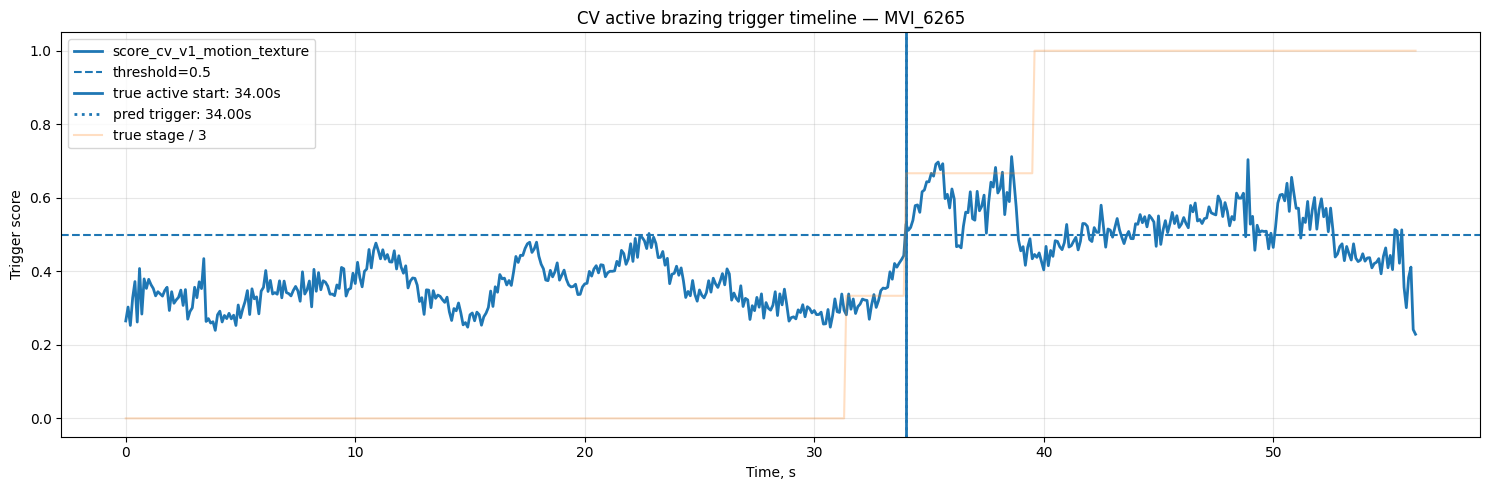

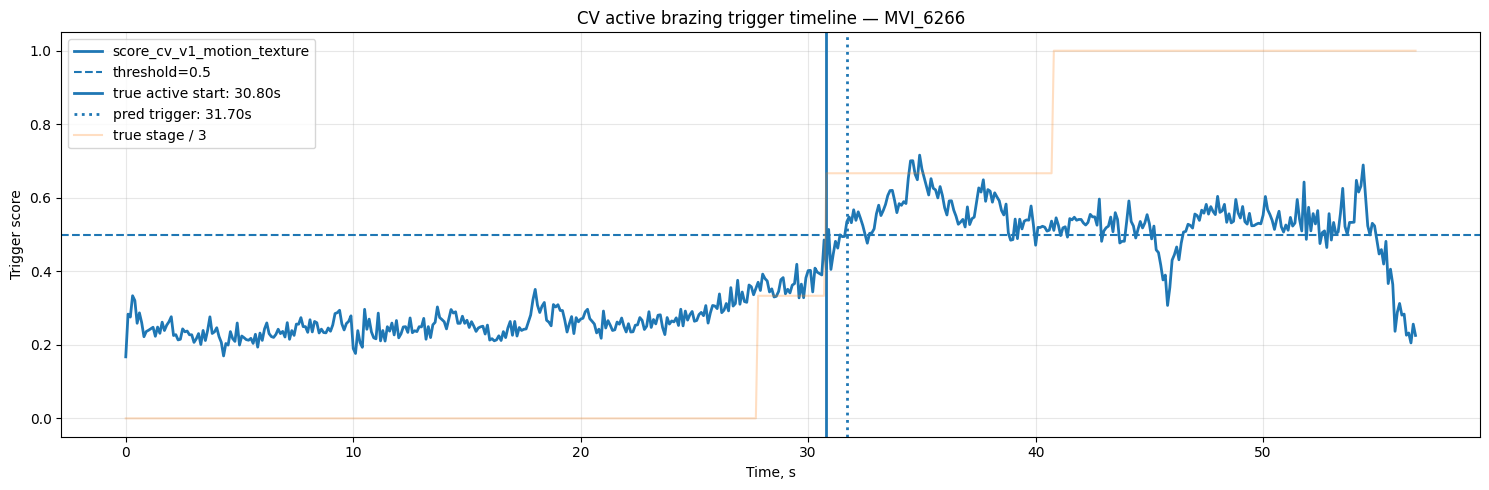

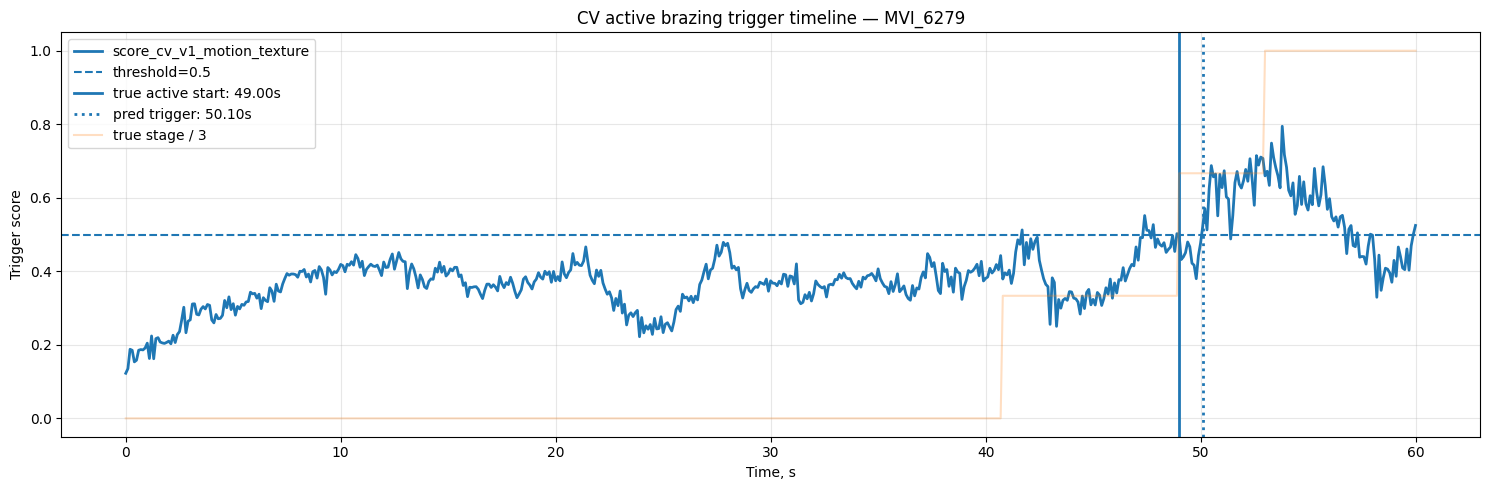

In [18]:
for video_id in sorted(cv_test_df["video_id"].unique()):
    plot_trigger_timeline(
        cv_test_df,
        true_active_start_df,
        video_id=video_id,
        score_col=best_score_col,
        threshold=best_threshold,
        confirm_frames=best_confirm_frames,
        output_name=f"{video_id}_best_cv_rule_trigger.png",
    )

## Part-3: classical ML binary trigger on improved features

In [19]:
META_COLUMNS = {
    "video_id",
    "frame_path",
    "timestamp_s",
    "stage_id",
    "stage_name",
    "binary_active_brazing",
}

cv_feature_columns = [
    col for col in cv_train_df.columns
    if col not in META_COLUMNS
    and pd.api.types.is_numeric_dtype(cv_train_df[col])
]

len(cv_feature_columns), cv_feature_columns[:20]

(172,
 ['brightness_mean',
  'brightness_std',
  'value_mean',
  'value_std',
  'saturation_mean',
  'saturation_std',
  'hue_mean',
  'lab_l_mean',
  'lab_a_mean',
  'lab_b_mean',
  'red_mean',
  'green_mean',
  'blue_mean',
  'red_green_diff',
  'red_blue_diff',
  'white_area_ratio',
  'specular_highlight_ratio',
  'dark_area_ratio',
  'warm_area_ratio',
  'edge_density'])

### prepare X/y

In [20]:
X_train_df = cv_train_df[cv_feature_columns].replace([np.inf, -np.inf], np.nan)
X_val_df = cv_val_df[cv_feature_columns].replace([np.inf, -np.inf], np.nan)
X_test_df = cv_test_df[cv_feature_columns].replace([np.inf, -np.inf], np.nan)

median_values = X_train_df.median()

X_train = X_train_df.fillna(median_values).values
X_val = X_val_df.fillna(median_values).values
X_test = X_test_df.fillna(median_values).values

y_train = cv_train_df["binary_active_brazing"].values
y_val = cv_val_df["binary_active_brazing"].values
y_test = cv_test_df["binary_active_brazing"].values

X_train.shape, X_val.shape, X_test.shape

((5755, 172), (1091, 172), (1732, 172))

### train binary models

In [21]:
binary_models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42,
    ),
}

binary_model_rows = []

for name, model in binary_models.items():
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    binary_model_rows.append({
        "model": name,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_precision": precision_score(y_val, val_pred, zero_division=0),
        "val_recall": recall_score(y_val, val_pred, zero_division=0),
        "val_f1": f1_score(y_val, val_pred, zero_division=0),
    })

binary_model_metrics_df = pd.DataFrame(binary_model_rows).sort_values(
    "val_f1",
    ascending=False,
)

binary_model_metrics_df

,model,val_accuracy,val_precision,val_recall,val_f1
1,RandomForest,0.931256,0.898734,0.514493,0.654378
2,GradientBoosting,0.901925,0.602649,0.659420,0.629758
0,LogisticRegression,0.856095,0.454976,0.695652,0.550143


### test binary models frame-level

In [22]:
binary_test_rows = []

for name, model in binary_models.items():
    test_pred = model.predict(X_test)

    binary_test_rows.append({
        "model": name,
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
    })

binary_test_metrics_df = pd.DataFrame(binary_test_rows).sort_values(
    "test_f1",
    ascending=False,
)

binary_test_metrics_df

,model,test_accuracy,test_precision,test_recall,test_f1
1,RandomForest,0.915127,0.644970,0.556122,0.597260
0,LogisticRegression,0.655312,0.246523,0.994898,0.395137
2,GradientBoosting,0.678984,0.242857,0.867347,0.379464


### event grid for binary ML models

In [23]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
confirm_frames_values = [1, 2, 3, 5, 7, 10]

binary_event_rows = []

for model_name, model in binary_models.items():
    if hasattr(model, "predict_proba"):
        test_score = model.predict_proba(X_test)[:, 1]
    else:
        test_score = model.predict(X_test)

    candidate_df = cv_test_df.copy()
    candidate_df[f"score_binary_{model_name}"] = test_score

    for threshold in thresholds:
        for confirm_frames in confirm_frames_values:
            event_df = evaluate_event_trigger(
                candidate_df,
                true_active_start_df,
                score_col=f"score_binary_{model_name}",
                threshold=threshold,
                confirm_frames=confirm_frames,
            )

            summary = summarize_event_results(event_df)

            binary_event_rows.append({
                "method": "cv_binary_ml",
                "model": model_name,
                "score_col": f"score_binary_{model_name}",
                "threshold": threshold,
                "confirm_frames": confirm_frames,
                **summary,
            })

binary_event_grid_df = pd.DataFrame(binary_event_rows).sort_values(
    ["mae_s", "num_missed", "max_abs_error_s"],
    ascending=[True, True, True],
)

binary_event_grid_df.head(30)

,method,model,score_col,threshold,confirm_frames,num_videos,num_detected,num_missed,num_early,num_late,mae_s,mean_error_s,median_abs_error_s,max_abs_error_s,within_1.0s,within_2.0s
48,cv_binary_ml,RandomForest,score_binary_RandomForest,0.6,1,3,2,1,1,1,1.500000,-0.800000,1.5,2.3,0.500000,0.500000
49,cv_binary_ml,RandomForest,score_binary_RandomForest,0.6,2,3,2,1,1,1,1.500000,-0.800000,1.5,2.3,0.500000,0.500000
50,cv_binary_ml,RandomForest,score_binary_RandomForest,0.6,3,3,2,1,1,1,1.500000,-0.800000,1.5,2.3,0.500000,0.500000
51,cv_binary_ml,RandomForest,score_binary_RandomForest,0.6,5,3,2,1,1,1,1.500000,-0.800000,1.5,2.3,0.500000,0.500000
52,cv_binary_ml,RandomForest,score_binary_RandomForest,0.6,7,3,2,1,1,1,1.500000,-0.800000,1.5,2.3,0.500000,0.500000
53,cv_binary_ml,RandomForest,score_binary_RandomForest,0.6,10,3,2,1,1,1,1.500000,-0.800000,1.5,2.3,0.500000,0.500000
46,cv_binary_ml,RandomForest,score_binary_RandomForest,0.5,7,3,2,1,1,1,1.500000,-0.900000,1.5,2.4,0.500000,0.500000
47,cv_binary_ml,RandomForest,score_binary_RandomForest,0.5,10,3,2,1,1,1,1.500000,-0.900000,1.5,2.4,0.500000,0.500000
54,cv_binary_ml,RandomForest,score_binary_RandomForest,0.7,1,3,2,1,1,1,1.500000,-0.600000,1.5,2.1,0.500000,0.500000
55,cv_binary_ml,RandomForest,score_binary_RandomForest,0.7,2,3,2,1,1,1,1.500000,-0.600000,1.5,2.1,0.500000,0.500000


In [24]:
binary_event_grid_df.to_csv(
    OUTPUT_DIR / "cv_binary_ml_trigger_grid.csv",
    index=False,
)

### best binary ML trigger timeline

In [25]:
best_binary_event = binary_event_grid_df.iloc[0].to_dict()
best_binary_event

{'method': 'cv_binary_ml',
 'model': 'RandomForest',
 'score_col': 'score_binary_RandomForest',
 'threshold': 0.6,
 'confirm_frames': 1,
 'num_videos': 3,
 'num_detected': 2,
 'num_missed': 1,
 'num_early': 1,
 'num_late': 1,
 'mae_s': 1.4999999999999982,
 'mean_error_s': -0.7999999999999989,
 'median_abs_error_s': 1.4999999999999982,
 'max_abs_error_s': 2.299999999999997,
 'within_1.0s': 0.5,
 'within_2.0s': 0.5}

In [26]:
best_binary_model_name = best_binary_event["model"]
best_binary_score_col = best_binary_event["score_col"]
best_binary_threshold = float(best_binary_event["threshold"])
best_binary_confirm_frames = int(best_binary_event["confirm_frames"])

best_binary_model = binary_models[best_binary_model_name]

if hasattr(best_binary_model, "predict_proba"):
    best_binary_scores = best_binary_model.predict_proba(X_test)[:, 1]
else:
    best_binary_scores = best_binary_model.predict(X_test)

best_binary_trigger_df = cv_test_df.copy()
best_binary_trigger_df[best_binary_score_col] = best_binary_scores

best_binary_event_df = evaluate_event_trigger(
    best_binary_trigger_df,
    true_active_start_df,
    score_col=best_binary_score_col,
    threshold=best_binary_threshold,
    confirm_frames=best_binary_confirm_frames,
)

best_binary_event_df

,video_id,true_start_s,pred_start_s,error_s,abs_error_s,trigger_type,threshold,confirm_frames,score_col,within_1.0s,within_2.0s
0,MVI_6265,34.0,NaN,NaN,NaN,missed,0.6,1,score_binary_RandomForest,False,False
1,MVI_6266,30.8,31.5,0.7,0.7,late,0.6,1,score_binary_RandomForest,True,True
2,MVI_6279,49.0,46.7,-2.3,2.3,early,0.6,1,score_binary_RandomForest,False,False


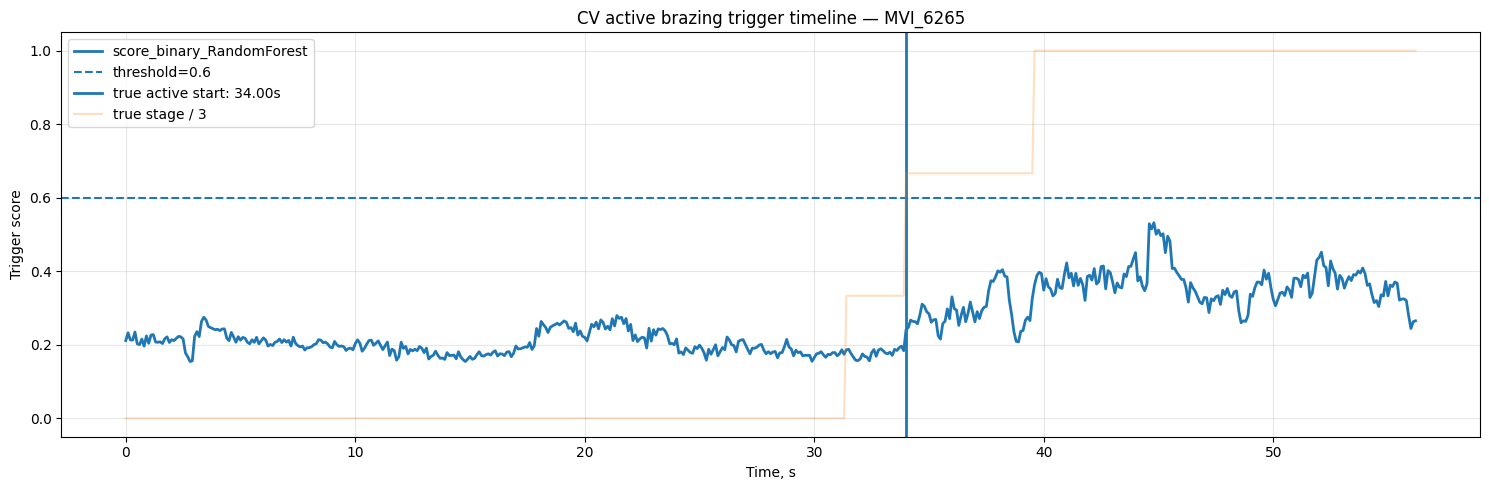

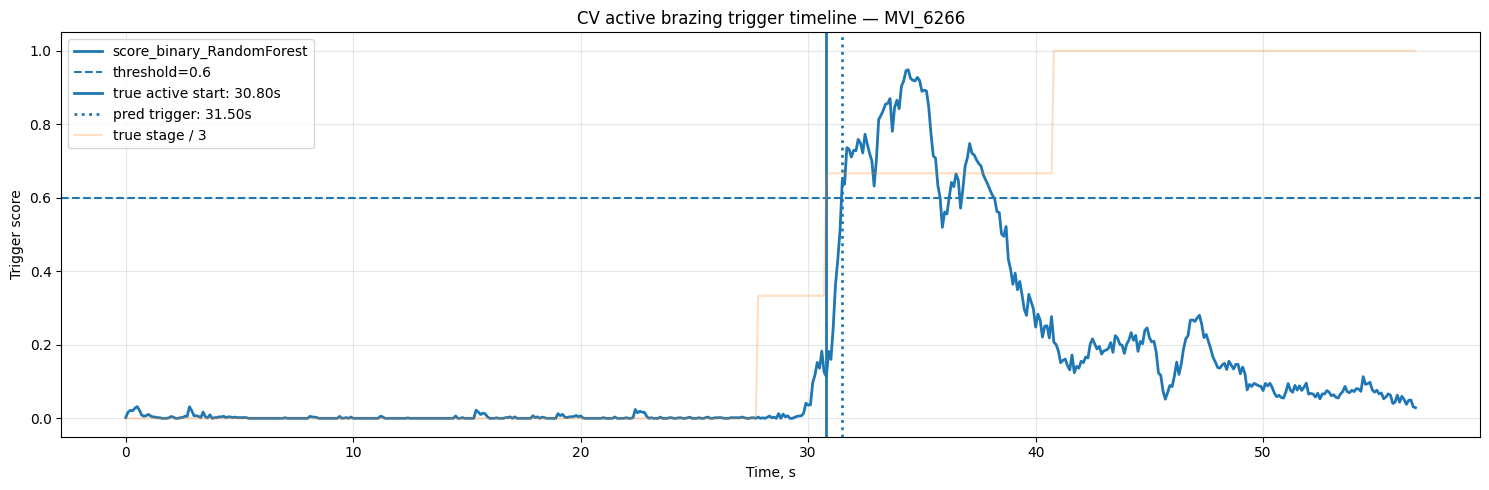

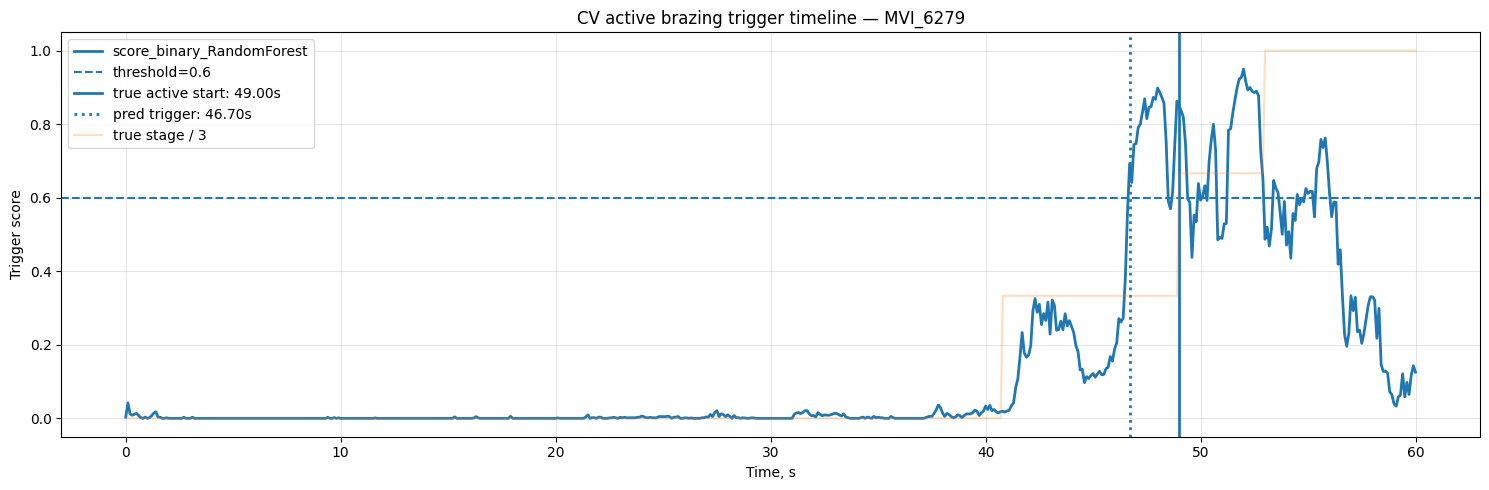

In [27]:
for video_id in sorted(best_binary_trigger_df["video_id"].unique()):
    plot_trigger_timeline(
        best_binary_trigger_df,
        true_active_start_df,
        video_id=video_id,
        score_col=best_binary_score_col,
        threshold=best_binary_threshold,
        confirm_frames=best_binary_confirm_frames,
        output_name=f"{video_id}_best_cv_binary_ml_trigger.png",
    )

## Part-4: compare

In [28]:
stage_prob_summary_df = pd.read_csv(STAGE_PROB_TRIGGER_SUMMARY_PATH)
display(stage_prob_summary_df)

stage_prob_reference = stage_prob_summary_df[
    stage_prob_summary_df["method"] == "stage_model_prob_active_brazing"
].copy()

if len(stage_prob_reference) > 0:
    stage_prob_reference = stage_prob_reference.iloc[0].to_dict()

stage_prob_reference

,method,threshold,confirm_frames,num_videos,num_detected,num_missed,num_early,num_late,mae_s,mean_error_s,median_abs_error_s,max_abs_error_s,within_1.0s,within_2.0s
0,stage_model_prob_active_brazing,0.2,7,3,3,0,0,3,0.70,0.70,0.90,1.0,1.000000,1.0
1,cv_rule_trigger,0.5,5,3,3,0,1,2,0.90,-0.30,0.60,1.8,0.666667,1.0
2,cv_binary_model_RandomForest,0.6,7,3,2,1,0,2,0.95,0.95,0.95,1.5,0.500000,1.0


{'method': 'stage_model_prob_active_brazing',
 'threshold': 0.2,
 'confirm_frames': 7,
 'num_videos': 3,
 'num_detected': 3,
 'num_missed': 0,
 'num_early': 0,
 'num_late': 3,
 'mae_s': 0.6999999999999993,
 'mean_error_s': 0.6999999999999993,
 'median_abs_error_s': 0.8999999999999986,
 'max_abs_error_s': 1.0,
 'within_1.0s': 1.0,
 'within_2.0s': 1.0}

In [29]:
summary_rows = []

if stage_prob_reference is not None:
    summary_rows.append({
        "method": "stage_model_prob_active_brazing",
        "score_col": "prob_active_brazing",
        "threshold": stage_prob_reference["threshold"],
        "confirm_frames": stage_prob_reference["confirm_frames"],
        "num_videos": stage_prob_reference["num_videos"],
        "num_detected": stage_prob_reference["num_detected"],
        "num_missed": stage_prob_reference["num_missed"],
        "num_early": stage_prob_reference["num_early"],
        "num_late": stage_prob_reference["num_late"],
        "mae_s": stage_prob_reference["mae_s"],
        "max_abs_error_s": stage_prob_reference["max_abs_error_s"],
        "within_1.0s": stage_prob_reference["within_1.0s"],
        "within_2.0s": stage_prob_reference["within_2.0s"],
    })

summary_rows.append({
    "method": "best_cv_rule",
    "score_col": best_cv_rule["score_col"],
    "threshold": best_cv_rule["threshold"],
    "confirm_frames": best_cv_rule["confirm_frames"],
    **summarize_event_results(best_cv_rule_event_df),
})

summary_rows.append({
    "method": f"best_cv_binary_ml_{best_binary_model_name}",
    "score_col": best_binary_score_col,
    "threshold": best_binary_threshold,
    "confirm_frames": best_binary_confirm_frames,
    **summarize_event_results(best_binary_event_df),
})

final_trigger_comparison_df = pd.DataFrame(summary_rows)
final_trigger_comparison_df

,method,score_col,threshold,confirm_frames,num_videos,num_detected,num_missed,num_early,num_late,mae_s,max_abs_error_s,within_1.0s,within_2.0s,mean_error_s,median_abs_error_s
0,stage_model_prob_active_brazing,prob_active_brazing,0.2,7,3,3,0,0,3,0.700000,1.0,1.000000,1.0,NaN,NaN
1,best_cv_rule,score_cv_v1_motion_texture,0.5,5,3,3,0,0,2,0.666667,1.1,0.666667,1.0,0.666667,0.9
2,best_cv_binary_ml_RandomForest,score_binary_RandomForest,0.6,1,3,2,1,1,1,1.500000,2.3,0.500000,0.5,-0.800000,1.5


In [30]:
final_trigger_comparison_df.to_csv(
    OUTPUT_DIR / "final_cv_trigger_comparison.csv",
    index=False,
)

# result

 Итоговый вывод по CV active_brazing trigger

В данном ноутбуке была отдельно проверена возможность построения лёгкого OpenCV-триггера начала активной пайки. Такой триггер рассматривается как резервный и объяснимый сигнал, который может быть полезен в условиях ограничений на применение нейросетевой модели на целевом оборудовании.

Были проверены два основных CV-подхода:

1. Правило на основе OpenCV-признаков ROI.
2. Бинарные classical ML-модели на расширенных OpenCV-признаках.

Наилучший результат среди CV-подходов показало простое правило `score_cv_v1_motion_texture`, объединяющее признаки межкадрового изменения, текстурности, плотности границ и бликов.

Параметры лучшего CV-rule trigger:

```text
score_col:      score_cv_v1_motion_texture
threshold:      0.5
confirm_frames: 5
````

Результаты по событию начала `active_brazing`:

```text
num_detected:   3/3
num_missed:     0
num_early:      0
num_late:       2
MAE:            0.67 s
max_abs_error:  1.1 s
within_1.0s:    66.7%
within_2.0s:    100%
```

Таким образом, CV-rule trigger смог обнаружить начало активной пайки на всех тестовых видео без пропусков и без ранних срабатываний. Ошибка времени срабатывания во всех случаях не превышала 2 секунд.

Для сравнения, trigger на основе вероятности `P(active_brazing)` финальной нейросетевой модели показал:

```text
MAE:            0.70 s
max_abs_error:  1.0 s
within_1.0s:    100%
within_2.0s:    100%
```

Следовательно, нейросетевой trigger остаётся наиболее стабильным основным вариантом, однако CV-rule trigger является практически пригодным fallback-решением. Он не требует запуска нейросетевой модели и основан на интерпретируемых признаках изображения: межкадровом изменении, текстурности, границах и бликах.

Бинарные classical ML-модели на OpenCV-признаках показали менее устойчивый результат. Лучшей моделью оказался RandomForest, однако для event-задачи он обнаружил только 2 из 3 тестовых видео и уступил простому CV-rule trigger по устойчивости срабатывания.

Итог: в финальной архитектуре можно рассматривать два независимых сигнала начала активной пайки:

```text
Основной trigger:
ResNet18 stage classifier → P(active_brazing) → threshold + confirmation

Fallback trigger:
OpenCV ROI features → score_cv_v1_motion_texture → threshold + confirmation
```

CV-trigger не заменяет нейросетевой stage-модуль, но может использоваться как лёгкий резервный индикатор начала активной пайки или как объяснимый диагностический сигнал.

````

## Финальная архитектура теперь прям красивая

```text
1. Stage monitoring:
   ResNet18 10 FPS → state machine v1 → stable operator stage

2. Main active_brazing trigger:
   ResNet18 → P(active_brazing) → threshold 0.2 + 7-frame confirmation

3. Fallback CV trigger:
   OpenCV score_cv_v1_motion_texture → threshold 0.5 + 5-frame confirmation
````